# Data Cleaning & Preparation
**Role in project:** Python is used only for cleaning, validation and feature creation.
The deep analysis happens in **SQL**, **Excel**, **Power BI** and **Tableau**.

`ecommerce_sales.csv` → **clean + validate** → `ecommerce_sales_clean.csv` → SQL / Excel / Power BI / Tableau

## 1. Import Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

## 2. Load Dataset

In [2]:
paths = ["../data/ecommerce_sales.csv", "data/ecommerce_sales.csv", "ecommerce_sales.csv"]
path = next((p for p in paths if os.path.exists(p)), None)
if path is None:  # Google Colab: upload the CSV when asked
    from google.colab import files
    files.upload(); path = "ecommerce_sales.csv"
df = pd.read_csv(path, parse_dates=["Order_Date"])
df.head()

,Order_ID,Order_Date,Customer_ID,Product,Category,Region,City,Quantity,Unit_Price,Discount,Sales,Cost,Profit,Payment_Mode
0,ORD-100001,2024-01-01,C1083,Pen Set,Stationery,South,Hyderabad,2,285.0,0.05,541.5,293.23,248.27,UPI
1,ORD-100002,2024-01-01,C1035,Sofa Set,Furniture,North,Lucknow,2,30637.0,0.20,49019.2,54419.49,-5400.29,Cash on Delivery
2,ORD-100003,2024-01-02,C1064,Desk Organizer,Stationery,East,Kolkata,1,678.0,0.10,610.2,367.87,242.33,UPI
3,ORD-100004,2024-01-02,C1269,Smartphone,Electronics,West,Pune,2,30191.0,0.10,54343.8,46500.69,7843.11,Cash on Delivery
4,ORD-100005,2024-01-03,C1020,Air Fryer,Home & Kitchen,East,Kolkata,3,6908.0,0.00,20724.0,12875.59,7848.41,Cash on Delivery


## 3. Data Overview

In [3]:
print("Shape:", df.shape)
print("Date range:", df["Order_Date"].min().date(), "to", df["Order_Date"].max().date())
df.info()

Shape: (2000, 14)
Date range: 2024-01-01 to 2025-12-31
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order_ID      2000 non-null   str           
 1   Order_Date    2000 non-null   datetime64[us]
 2   Customer_ID   2000 non-null   str           
 3   Product       2000 non-null   str           
 4   Category      2000 non-null   str           
 5   Region        2000 non-null   str           
 6   City          2000 non-null   str           
 7   Quantity      2000 non-null   int64         
 8   Unit_Price    2000 non-null   float64       
 9   Discount      2000 non-null   float64       
 10  Sales         2000 non-null   float64       
 11  Cost          2000 non-null   float64       
 12  Profit        2000 non-null   float64       
 13  Payment_Mode  2000 non-null   str           
dtypes: datetime64[us](1), float64(5), int64(1), 

## 4. Data Cleaning & Validation

In [4]:
print("Missing values:", int(df.isnull().sum().sum()))
print("Duplicate Order_IDs:", df["Order_ID"].duplicated().sum())

for col in ["Product", "Category", "Region", "City"]:
    df[col] = df[col].str.strip().str.title()
df = df.drop_duplicates(subset="Order_ID").reset_index(drop=True)

# Business-rule checks
assert (df["Quantity"] > 0).all()
assert df["Discount"].between(0, 1).all()
assert np.allclose(df["Quantity"] * df["Unit_Price"] * (1 - df["Discount"]), df["Sales"], atol=0.02)
assert np.allclose(df["Sales"] - df["Cost"], df["Profit"], atol=0.02)
print("All validation checks passed. Rows:", len(df))

Missing values: 0
Duplicate Order_IDs: 0
All validation checks passed. Rows: 2000


## 5. Feature Creation

In [5]:
df["Year"] = df["Order_Date"].dt.year
df["Month"] = df["Order_Date"].dt.month
df["Year_Month"] = df["Order_Date"].dt.to_period("M").astype(str)
df["Profit_Margin_Pct"] = (df["Profit"] / df["Sales"] * 100).round(2)
df["Discount_Band"] = (df["Discount"] * 100).astype(int).astype(str) + "%"
df["Is_Loss"] = (df["Profit"] < 0).astype(int)
df[["Order_ID", "Year_Month", "Profit_Margin_Pct", "Discount_Band", "Is_Loss"]].head()

,Order_ID,Year_Month,Profit_Margin_Pct,Discount_Band,Is_Loss
0,ORD-100001,2024-01,45.85,5%,0
1,ORD-100002,2024-01,-11.02,20%,1
2,ORD-100003,2024-01,39.71,10%,0
3,ORD-100004,2024-01,14.43,10%,0
4,ORD-100005,2024-01,37.87,0%,0


## 6. Export Clean Data (used by SQL, Excel, Power BI, Tableau)

In [6]:
out = "../data/ecommerce_sales_clean.csv" if os.path.exists("../data") else "ecommerce_sales_clean.csv"
df.to_csv(out, index=False)
print("Saved:", out)

Saved: ../data/ecommerce_sales_clean.csv


## 7. Quick Exploratory Charts
Three charts for a first look. Full analysis is in the SQL, Excel and BI files.

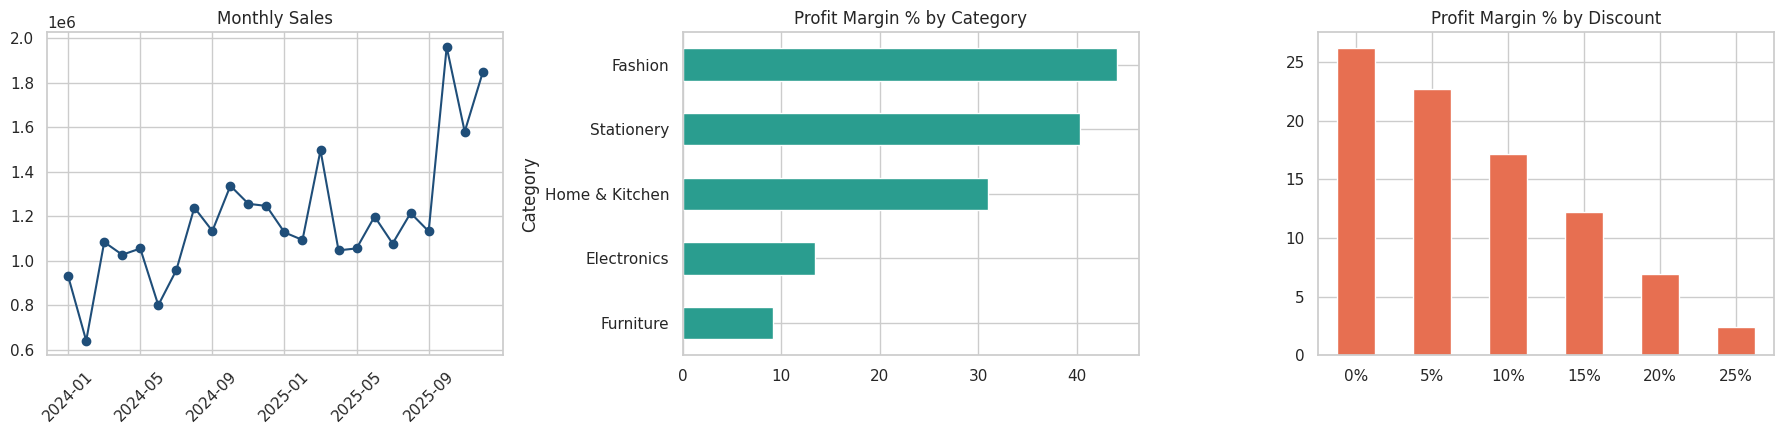

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
m = df.groupby("Year_Month")["Sales"].sum()
axes[0].plot(m.index, m.values, color="#1F4E79", marker="o"); axes[0].set_title("Monthly Sales")
axes[0].set_xticks(range(0, len(m), 4)); axes[0].set_xticklabels(m.index[::4], rotation=45)

c = df.groupby("Category")[["Sales", "Profit"]].sum()
(c["Profit"] / c["Sales"] * 100).sort_values().plot.barh(ax=axes[1], color="#2A9D8F")
axes[1].set_title("Profit Margin % by Category")

d = df.groupby("Discount_Band").agg(S=("Sales", "sum"), P=("Profit", "sum"))
d = d.sort_index(key=lambda s: s.str.rstrip("%").astype(int))
(d["P"] / d["S"] * 100).plot.bar(ax=axes[2], color="#E76F51", rot=0)
axes[2].set_title("Profit Margin % by Discount"); axes[2].set_xlabel("")
plt.tight_layout(); plt.show()

## Next Steps
- Run `sql/analysis.sql` for the full analysis
- Use `excel/ecommerce_sales_analysis.xlsx` for formula-based summaries
- Build dashboards in Power BI and Tableau from `data/ecommerce_sales_clean.csv`